# One-Line Diagram

When a 3-phase system is solved using per-phase equivalent, it can be further simplified by omitting the completed circuit through the neutral and by indicating the component parts by standard symbols rather than by their equivalent circuits. The American National Standards Institute (ANSI) and the Institute of Electrical and Electronics Engineers (IEEE) have published a set of standard symbols for electrical diagrams. Not all authors follow these symbols consistently, especially in
indicating transformers, below are a few commonly used symbols:

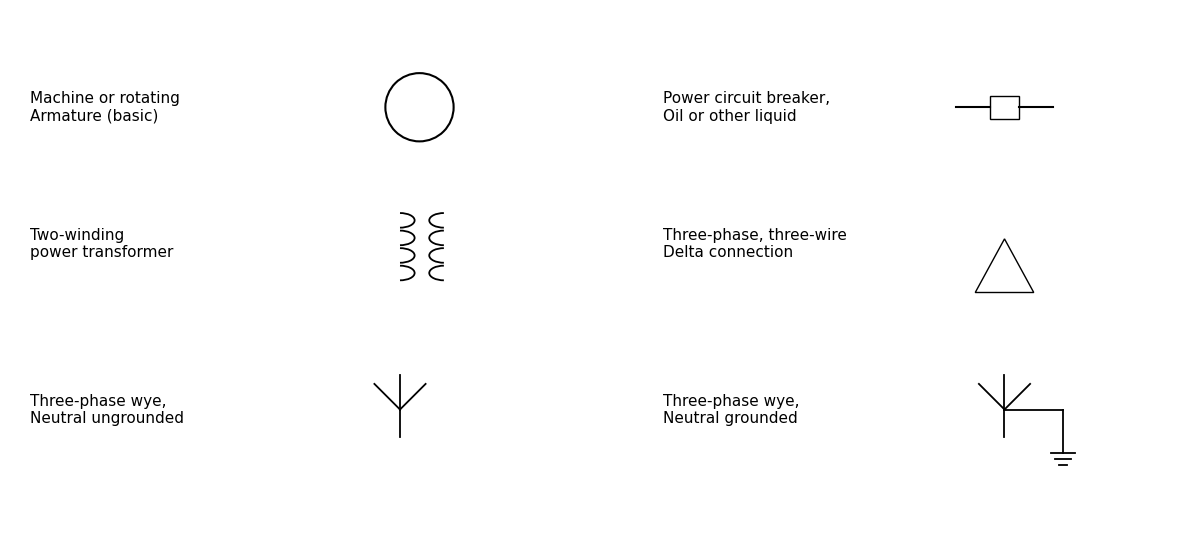

In [40]:
# TEST CELL
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, Polygon, Arc

fig, ax = plt.subplots(figsize=(12, 8))

# ---------- Symbols ----------
def machine(x,y):
    ax.add_patch(Circle((x,y),0.35,fill=False,lw=1.5))


def two_winding_transformer(x,y):
    for i in range(4):
        ax.add_patch(Arc((x,y+i*0.18),0.30,0.15,theta1=-90,theta2=90,lw=1.3))
    for i in range(4):
        ax.add_patch(Arc((x+0.45,y+i*0.18),0.30,0.15,theta1=90,theta2=270,lw=1.3))


def three_winding_transformer(x,y):
    for off in [0,0.45,0.90]:
        for i in range(4):
            if off==0.45:
                t1,t2=90,270
            else:
                t1,t2=-90,90
            ax.add_patch(Arc((x+off,y+i*0.18),0.30,0.15,theta1=t1,theta2=t2,lw=1.3))


def fuse(x,y):
    ax.plot([x-0.45,x-0.1],[y,y],'k')
    ax.add_patch(Rectangle((x-0.1,y-0.12),0.55,0.24,fill=False))
    ax.plot([x+0.45,x+0.8],[y,y],'k')


def current_transformer(x,y):
    ax.plot([x-0.4,x+0.6],[y,y],'k')
    for i in range(2):
        ax.add_patch(Arc((x+i*0.2,y),0.18,0.18,theta1=0,theta2=180,lw=1.2))


def voltage_transformer(x,y):
    ax.plot([x-0.35,x-0.05],[y,y],'k')
    ax.add_patch(Arc((x,y),0.22,0.22,theta1=-90,theta2=90,lw=1.2))
    ax.plot([x+0.11,x+0.35],[y,y],'k')


def oil_breaker(x,y):
    ax.plot([x-0.5,x-0.15],[y,y],'k')
    ax.add_patch(Rectangle((x-0.15,y-0.12),0.3,0.24,fill=False))
    ax.plot([x+0.15,x+0.5],[y,y],'k')


def air_breaker(x,y):
    ax.plot([x-0.5,x-0.1],[y,y],'k')
    t=np.linspace(0,np.pi,100)
    ax.plot(x+0.12*np.cos(t),y+0.12*np.sin(t),'k')
    ax.plot([x+0.12,x+0.5],[y,y],'k')


def delta(x,y):
    ax.add_patch(Polygon([[x,y+0.35],[x-0.3,y-0.2],[x+0.3,y-0.2]],fill=False))


def wye_ungrounded(x, y, size=0.35):
    # upper branch
    ax.plot([x, x], [y, y + size], 'k', lw=1.3)

    # left branch
    ax.plot([x, x - size * 0.75],
            [y, y + size * 0.75],
            'k', lw=1.3)

    # right branch
    ax.plot([x, x + size * 0.75],
            [y, y + size * 0.75],
            'k', lw=1.3)

    # downward neutral leg
    ax.plot([x, x],
            [y, y - size * 0.8],
            'k', lw=1.3)



def wye_grounded(x, y, size=0.35):
    # wye symbol
    wye_ungrounded(x, y, size)

    # neutral routed to right
    y_neutral = y - size * 0.0

    ax.plot([x, x + 0.6],
            [y_neutral, y_neutral],
            'k', lw=1.3)

    # drop to ground
    ax.plot([x + 0.6, x + 0.6],
            [y_neutral, y_neutral - 0.45],
            'k', lw=1.3)

    gx = x + 0.6
    gy = y_neutral - 0.45

    # earth ground symbol
    ax.plot([gx - 0.12, gx + 0.12], [gy, gy], 'k', lw=1.3)
    ax.plot([gx - 0.08, gx + 0.08], [gy - 0.06, gy - 0.06], 'k', lw=1.3)
    ax.plot([gx - 0.04, gx + 0.04], [gy - 0.12, gy - 0.12], 'k', lw=1.3)





def meter(x,y,label):
    ax.plot([x-0.5,x-0.22],[y,y],'k')
    ax.add_patch(Circle((x,y),0.22,fill=False))
    ax.text(x,y,label,ha='center',va='center')
    ax.plot([x+0.22,x+0.5],[y,y],'k')

# ---------- Left column ----------
items_y=[10,8.6,6.9]#,5.2,3.9,2.7,1.4]
ax.text(0.2,10,'Machine or rotating\nArmature (basic)',fontsize=11,va='center'); machine(4.2,10)
ax.text(0.2,8.6,'Two-winding\npower transformer',fontsize=11,va='center'); two_winding_transformer(4.0,8.3)
#ax.text(0.2,6.9,'Three-winding\npower transformer',fontsize=11,va='center'); three_winding_transformer(3.8,6.6)
#ax.text(0.2,5.2,'Fuse',fontsize=11,va='center'); fuse(4.0,5.2)
#ax.text(0.2,3.9,'Current transformer',fontsize=11,va='center'); current_transformer(4.0,3.9)
#ax.text(0.2,2.7,'Voltage transformer',fontsize=11,va='center'); voltage_transformer(4.0,2.7)
#ax.text(0.2,1.4,'Ammeter and voltmeter',fontsize=11,va='center'); meter(7.6,1.4,'A'); meter(9.5,1.4,'V')

# ---------- Right column ----------
ax.text(6.7,10,'Power circuit breaker,\nOil or other liquid',fontsize=11,va='center'); oil_breaker(10.2,10)
#ax.text(6.7,8.3,'Air circuit breaker',fontsize=11,va='center'); air_breaker(10.2,8.3)
ax.text(6.7,8.6,'Three-phase, three-wire\nDelta connection',fontsize=11,va='center'); delta(10.2,8.3)
ax.text(0.2,6.9,'Three-phase wye,\nNeutral ungrounded',fontsize=11,va='center'); wye_ungrounded(4,6.9)
ax.text(6.7,6.9,'Three-phase wye,\nNeutral grounded',fontsize=11,va='center'); wye_grounded(10.2,6.9)

ax.set_xlim(0,12)
ax.set_ylim(5.5,11)
ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout()
plt.show()


## Example of one-line diagram

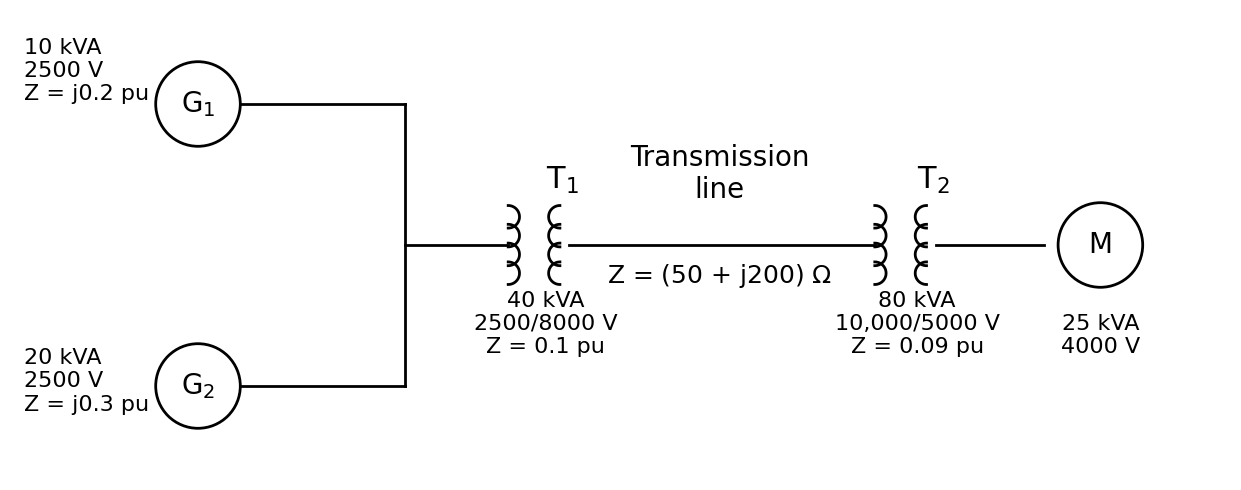

In [8]:
# TEST CELL
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

fig, ax = plt.subplots(figsize=(14, 5))


def draw_machine(x, y, label, radius=0.45):
    c = Circle((x, y), radius, fill=False, linewidth=2)
    ax.add_patch(c)
    ax.text(x, y, label, ha='center', va='center', fontsize=20)


def draw_transformer(x, y):
    r = 0.12
    turns = 4

    # left coil ))))
    for i in range(turns):
        yc = y - 0.30 + i * 0.20
        t = np.linspace(-np.pi/2, np.pi/2, 100)
        ax.plot(x + r*np.cos(t), yc + r*np.sin(t), 'k', lw=2)

    # right coil ((((
    for i in range(turns):
        yc = y - 0.30 + i * 0.20
        t = np.linspace(np.pi/2, 3*np.pi/2, 100)
        ax.plot(x + 0.55 + r*np.cos(t), yc + r*np.sin(t), 'k', lw=2)


# Generators
G1x, G1y = 2.0, 4.0
G2x, G2y = 2.0, 1.0

busx = 4.2
midy = 2.5

# Draw machines

draw_machine(G1x, G1y, r'G$_1$')
draw_machine(G2x, G2y, r'G$_2$')

# Labels
ax.text(0.15, 4.35, '10 kVA\n2500 V\nZ = j0.2 pu', fontsize=16, va='center')
ax.text(0.15, 1.05, '20 kVA\n2500 V\nZ = j0.3 pu', fontsize=16, va='center')

# Bus and connections
ax.plot([G1x+0.45, busx], [G1y, G1y], 'k', lw=2)
ax.plot([G2x+0.45, busx], [G2y, G2y], 'k', lw=2)
ax.plot([busx, busx], [G2y, G1y], 'k', lw=2)

# T1
ax.plot([busx, 5.3], [midy, midy], 'k', lw=2)
draw_transformer(5.3, midy)
ax.text(5.7, 3.1, r'T$_1$', fontsize=22)
ax.text(5.7, 1.35, '40 kVA\n2500/8000 V\nZ = 0.1 pu', fontsize=16, ha='center')

# Transmission line
ax.plot([5.95, 9.2], [midy, midy], 'k', lw=2)
ax.text(7.55, 3.0, 'Transmission\nline', fontsize=20, ha='center')
ax.text(7.55, 2.1, r'Z = (50 + j200) $\Omega$', fontsize=18, ha='center')

# T2

draw_transformer(9.2, midy)
ax.text(9.65, 3.1, r'T$_2$', fontsize=22)
ax.text(9.65, 1.35, '80 kVA\n10,000/5000 V\nZ = 0.09 pu', fontsize=16, ha='center')

# Motor
ax.plot([9.85, 11.0], [midy, midy], 'k', lw=2)
draw_machine(11.6, midy, 'M')
ax.text(11.6, 1.35, '25 kVA\n4000 V', fontsize=16, ha='center')

ax.set_xlim(0, 13)
ax.set_ylim(0, 5)
ax.set_aspect('equal')
ax.axis('off')

plt.tight_layout()
plt.show()


## Impedance Diagram
The per-Phase Impedance Diagram Corresponding to the Single-Line Diagram

Per-unit quantities
G1 = j1.000 pu
G2 = j0.750 pu
T1 = j0.125 pu
Line = 0.039 + j0.156 pu
T2 = j0.088 pu
M  = j0.500 pu


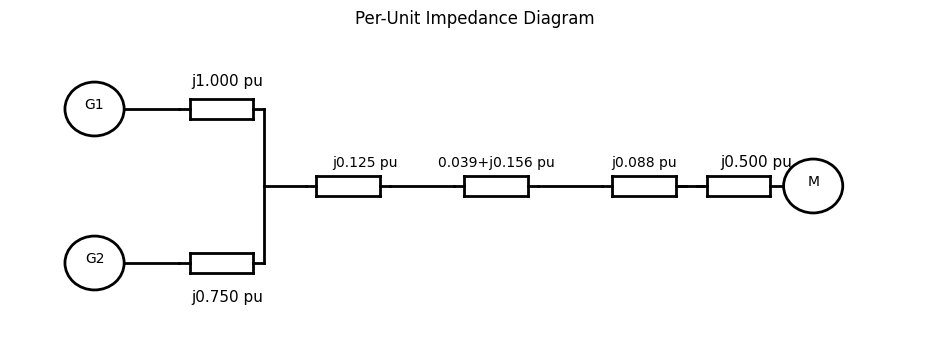

In [101]:
# TEST CELL
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# Problem 2.14 - Per-unit reactance diagram
# Base: 50 kVA

S_base = 50.0  # kVA

# Component data
X_G1 = 0.2 * (S_base/10)            # = j1.0 pu
X_G2 = 0.3 * (S_base/20)            # = j0.75 pu
X_T1 = 0.1 * (S_base/40)            # = j0.125 pu

# Transmission line
Z_line_actual = 50 + 1j*200     # ohms
Vbase_line = 8000.0             # V
Zbase_line = (Vbase_line**2)/(S_base*10**3)
Z_line_pu = Z_line_actual/Zbase_line

# Transformer T2
X_T2 = 0.09 * (S_base/80) * (10000/8000)**2

# Motor
X_M = 0.5

print('Per-unit quantities')
print(f'G1 = j{X_G1:.3f} pu')
print(f'G2 = j{X_G2:.3f} pu')
print(f'T1 = j{X_T1:.3f} pu')
print(f'Line = {Z_line_pu.real:.3f} + j{Z_line_pu.imag:.3f} pu')
print(f'T2 = j{X_T2:.3f} pu')
print(f'M  = j{X_M:.3f} pu')

# Reactance diagram
fig, ax = plt.subplots(figsize=(12,4))

def draw_resistor_iec(ax, x0=0, y0=0, length=0.75, height=0.25, lead=0.125, **kwargs):
    """
    Draw a European (IEC) resistor symbol.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axis to draw on.
    x0, y0 : float
        Centerline start position.
    length : float
        Length of resistor body.
    height : float
        Height of resistor body.
    lead : float
        Length of connection leads on each side.
    """

    # Left lead
    ax.plot([x0, x0 + lead], [y0, y0], **kwargs)

    # Resistor body (European rectangular style)
    x1 = x0 + lead
    x2 = x1 + length

    ax.plot([x1, x2], [y0 + height/2, y0 + height/2], **kwargs)
    ax.plot([x1, x2], [y0 - height/2, y0 - height/2], **kwargs)
    ax.plot([x1, x1], [y0 - height/2, y0 + height/2], **kwargs)
    ax.plot([x2, x2], [y0 - height/2, y0 + height/2], **kwargs)

    # Right lead
    ax.plot([x2, x2 + lead], [y0, y0], **kwargs)

    return x2 + lead, y0



# G1
ax.add_patch(Circle((1,3),0.35,fill=False,lw=2))
ax.text(1,3,'G1',ha='center')
ax.text(2.15,3.3,f'j{X_G1:.3f} pu',fontsize=11)
draw_resistor_iec(ax, x0=2, y0=3, color='k', lw=2)

# G2
ax.add_patch(Circle((1,1),0.35,fill=False,lw=2))
ax.text(1,1,'G2',ha='center')
ax.text(2.15,0.5,f'j{X_G2:.3f} pu',fontsize=11)
draw_resistor_iec(ax, x0=2, y0=1, color='k', lw=2)

# bus
ax.plot([1.35,2],[3,3],'k',lw=2)
ax.plot([1.35,2],[1,1],'k',lw=2)
ax.plot([3,3],[1,3],'k',lw=2)

# T1
ax.plot([3,3.5],[2,2],'k',lw=2)
ax.text(4.2,2.25,f'j{X_T1:.3f} pu',ha='center')
draw_resistor_iec(ax, x0=3.5, y0=2, color='k', lw=2)


# line
ax.plot([4.5,5.25],[2,2],'k',lw=2)
ax.plot([6.25,7],[2,2],'k',lw=2)
ax.text(5.75,2.25,f'{Z_line_pu.real:.3f}+j{Z_line_pu.imag:.3f} pu',ha='center')
draw_resistor_iec(ax, x0=5.25, y0=2, color='k', lw=2)


# T2
ax.plot([7.9,8.2],[2,2],'k',lw=2)
ax.text(7.5,2.25,f'j{X_T2:.3f} pu',ha='center')
draw_resistor_iec(ax, x0=7, y0=2, color='k', lw=2)


# motor
#ax.plot([7.9,9],[2,2],'k',lw=2)
ax.add_patch(Circle((9.5,2),0.35,fill=False,lw=2))
ax.text(9.5,2,'M',ha='center')
ax.text(8.4,2.25,f'j{X_M:.3f} pu',fontsize=11)
draw_resistor_iec(ax, x0=8.12, y0=2, color='k', lw=2)

ax.set_xlim(0,11)
ax.set_ylim(0,4)
ax.axis('off')
plt.title('Per-Unit Impedance Diagram')
plt.show()
